In [ ]:
!pip install qiskit qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


In [ ]:
qc_test = QuantumCircuit(3, 3)



In [ ]:
qc_test.h(1)
qc_test.cx(1, 2)

In [ ]:
qc_test.cx(0, 1)
qc_test.h(0)

In [ ]:
qc_test.measure(0, 0)
qc_test.measure(1, 1)

In [ ]:
with qc_test.if_test((qc_test.clbits[1], True)):
    qc_test.x(2)

with qc_test.if_test((qc_test.clbits[0], True)):
    qc_test.z(2)

In [ ]:
qc_test.measure(2, 2)

In [ ]:
print(qc_test.draw())


                    ┌───┐┌─┐                                                   »
q_0: ────────────■──┤ H ├┤M├───────────────────────────────────────────────────»
     ┌───┐     ┌─┴─┐└┬─┬┘└╥┘                                                   »
q_1: ┤ H ├──■──┤ X ├─┤M├──╫────────────────────────────────────────────────────»
     └───┘┌─┴─┐└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_2: ─────┤ X ├───────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├»
          └───┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
                      ║   ║ ┌────╨────┐               ┌────╨────┐              »
c: 3/═════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞══════════════»
                      1   0 └─────────┘               └─────────┘              »
«         
«q_0: ────
«         
«q_1: ────
«      ┌─┐
«q_2: ─┤M├
«      └╥┘
«c: 3/══╩═
«       2 


In [ ]:
simulator = AerSimulator()

ideal_result = simulator.run(
    qc_test,
    shots=1000
).result()

ideal_counts = ideal_result.get_counts()

print(ideal_counts)

{'011': 240, '010': 249, '000': 260, '001': 251}


In [ ]:
noise_model_dep = NoiseModel()

depolarizing_1q = depolarizing_error(0.1, 1)
depolarizing_2q = depolarizing_error(0.1, 2)

noise_model_dep.add_all_qubit_quantum_error(
    depolarizing_1q, ['h']
)

noise_model_dep.add_all_qubit_quantum_error(
    depolarizing_2q, ['cx']
)

print("10% depolarizing noise model created!")

10% depolarizing noise model created!


In [ ]:
noisy_result_dep = simulator.run(
    qc_test,
    shots=1000,
    noise_model=noise_model_dep
).result()

noisy_counts_dep = noisy_result_dep.get_counts()

print(noisy_counts_dep)

{'101': 25, '100': 22, '110': 26, '111': 25, '011': 230, '001': 227, '010': 217, '000': 228}


In [ ]:
noise_model_dep_0 = NoiseModel()

depolarizing_1q_0 = depolarizing_error(0.0, 1)
depolarizing_2q_0 = depolarizing_error(0.0, 2)

noise_model_dep_0.add_all_qubit_quantum_error(
    depolarizing_1q_0, ['h']
)

noise_model_dep_0.add_all_qubit_quantum_error(
    depolarizing_2q_0, ['cx']
)

In [ ]:
ideal_dep_result = simulator.run(
    qc_test,
    shots=1000,
    noise_model=noise_model_dep_0
).result()

ideal_dep_counts = ideal_dep_result.get_counts()

print(ideal_dep_counts)

{'011': 247, '010': 235, '000': 249, '001': 269}


In [ ]:
noise_levels_dep = np.arange(0, 0.21, 0.02)

success_rates_dep = []
all_counts_dep = []

for p in noise_levels_dep:

    # Create noise model
    noise_model = NoiseModel()

    depolarizing_1q = depolarizing_error(p, 1)
    depolarizing_2q = depolarizing_error(p, 2)

    noise_model.add_all_qubit_quantum_error(
        depolarizing_1q, ['h']
    )

    noise_model.add_all_qubit_quantum_error(
        depolarizing_2q, ['cx']
    )

    # Run simulation
    result = simulator.run(
        qc_test,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts = result.get_counts()

    # Save full measurement distribution
    all_counts_dep.append(counts)

    # Bob's result = leftmost bit
    correct = sum(
        count
        for bitstring, count in counts.items()
        if bitstring[0] == '0'
    )

    success_rate = correct / 1000
    success_rates_dep.append(success_rate)


print("Noise levels:")
print(noise_levels_dep)

print("\nSuccess rates:")
print(success_rates_dep)

Noise levels:
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2 ]

Success rates:
[1.0, 0.983, 0.961, 0.944, 0.922, 0.905, 0.863, 0.866, 0.859, 0.827, 0.828]


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    noise_levels * 100,
    np.array(success_rates) * 100,
    marker='o',
    label='Bit-flip noise'
)

plt.plot(
    noise_levels_dep * 100,
    np.array(success_rates_dep) * 100,
    marker='o',
    label='Depolarizing noise'
)

plt.xlabel("Noise probability (%)")
plt.ylabel("Success rate (%)")
plt.title("Quantum Teleportation Under Different Noise Models")

plt.legend()
plt.grid(True)

plt.show()

NameError: name 'noise_levels' is not defined

<Figure size 900x500 with 0 Axes>

In [ ]:
noise_levels_bitflip = np.arange(0, 0.21, 0.02)

success_rates_bitflip = [
    1.0, 0.955, 0.921, 0.896, 0.840,
    0.812, 0.782, 0.769, 0.715, 0.709, 0.671
]

In [ ]:
success_rates_depolarizing = [
    1.0, 0.983, 0.961, 0.944, 0.922,
    0.905, 0.863, 0.866, 0.859, 0.827, 0.828
]

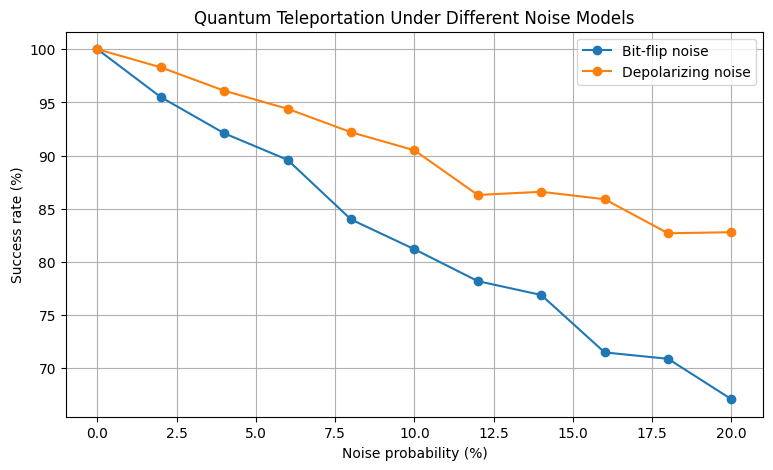

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    noise_levels_bitflip * 100,
    np.array(success_rates_bitflip) * 100,
    marker='o',
    label='Bit-flip noise'
)

plt.plot(
    noise_levels_bitflip * 100,
    np.array(success_rates_depolarizing) * 100,
    marker='o',
    label='Depolarizing noise'
)

plt.xlabel("Noise probability (%)")
plt.ylabel("Success rate (%)")
plt.title("Quantum Teleportation Under Different Noise Models")

plt.legend()
plt.grid(True)

plt.savefig(
    "noise_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()